# 03 — Fourier operators and trajectory forecasting

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## Learning objectives and input grid

I want to derive the spectral convolution, see how a function-to-function map
becomes tensors, audit causality, and interpret the accuracy–latency decision.

The operator grid concatenates 21 observed history locations and 30 future
query locations. At each of the 51 positions, the lifted feature vector contains

\[
[\text{values}_{9},\ \text{validity}_{9},\ \text{current}_{9},\
t/H,\ \sin(\pi t/H),\ \cos(\pi t/H),\ \mathbb 1_{observed}],
\]

for $3(9)+4=31$ channels. Future `values` and `validity` are zero; the repeated
current state and time/query flag are causal and known.

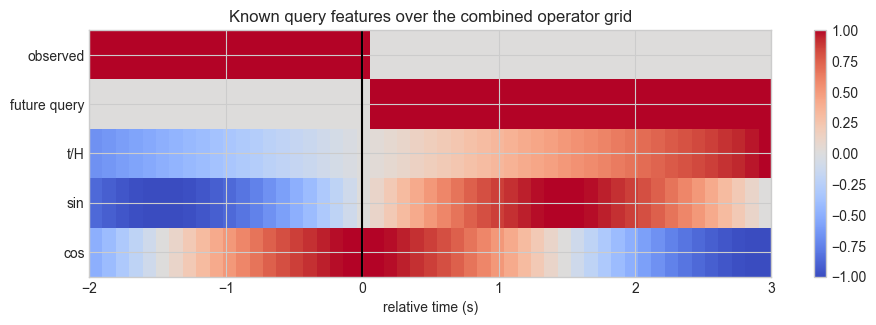

In [2]:
grid_t = np.r_[np.arange(-20,1)*.1, np.arange(1,31)*.1]
observed = grid_t <= 0
feature_map = np.vstack([
    observed.astype(float),
    (~observed).astype(float),
    grid_t / np.abs(grid_t).max(),
    np.sin(np.pi*grid_t/np.abs(grid_t).max()),
    np.cos(np.pi*grid_t/np.abs(grid_t).max()),
])
plt.figure(figsize=(11,3.2)); plt.imshow(feature_map, aspect='auto', cmap='coolwarm',
    extent=[grid_t.min(),grid_t.max(),4.5,-.5])
plt.yticks(range(5),['observed','future query','t/H','sin','cos'])
plt.axvline(0,color='black'); plt.xlabel('relative time (s)')
plt.title('Known query features over the combined operator grid'); plt.colorbar(); plt.show()

## The operator-learning view

A normal neural network maps finite vectors to finite vectors. An operator maps
one function to another. Here the input function is a masked state history on a
time grid; the output function is a future trajectory on query times.

An FNO block transforms along time, multiplies selected complex Fourier modes,
returns to the time domain, and adds a learned pointwise path:

\[
u_{l+1}=u_l+\sigma\left(Wu_l+\mathcal F^{-1}(R\mathcal F(u_l))\right).
\]

For $N$ grid points, the discrete Fourier transform is

\[
\hat u_k=\sum_{n=0}^{N-1}u_n e^{-2\pi i kn/N},\qquad
u_n=\frac1N\sum_{k=0}^{N-1}\hat u_k e^{2\pi i kn/N}.
\]

$R_k\in\mathbb C^{C_{in}\times C_{out}}$ mixes channels only for retained low
modes. The $1\times1$ convolution $W$ preserves a local path, while the spectral
path gives a global receptive field in a single block.

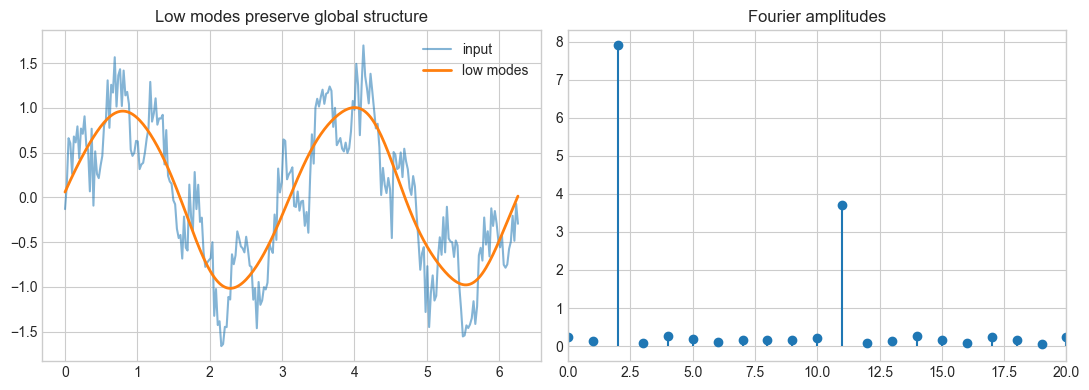

In [3]:
t = np.linspace(0, 2*np.pi, 256, endpoint=False)
signal = np.sin(2*t) + .45*np.sin(11*t) + .20*np.random.default_rng(4).normal(size=len(t))
spectrum = np.fft.rfft(signal, norm='ortho')
low = spectrum.copy(); low[8:] = 0
restored = np.fft.irfft(low, n=len(t), norm='ortho')
fig, ax = plt.subplots(1,2,figsize=(11,4))
ax[0].plot(t, signal, alpha=.55, label='input'); ax[0].plot(t, restored, lw=2, label='low modes')
ax[0].legend(); ax[0].set_title('Low modes preserve global structure')
ax[1].stem(np.abs(spectrum), basefmt=' '); ax[1].set_xlim(0,20); ax[1].set_title('Fourier amplitudes');
plt.tight_layout(); plt.show()

## Architecture, shapes, and residual parameterization

```text
$B\times51\times31$ ─ lift 31→96 ─ transpose ─ 4 Fourier blocks
                    ─ remove 8 padded steps ─ project 96→96→2
                    ─ keep 30 future rows ─ add CTRV ─ $B\times30\times2$
```

With $C=96$ and $M=16$ modes, each complex spectral layer learns approximately
$2C^2M$ real numbers, plus its local $C^2$ mixing. Spectral capacity therefore
grows as $O(C^2M)$ rather than $O(N^2)$ pairwise time interactions.

## Causality despite global mixing

Fourier convolution is global over the supplied grid. Causality therefore comes
from **what is supplied**, not from a triangular attention mask. Future slots
contain only query time, an observed/future flag, missingness zeros, and the
repeated current state. No future vehicle state or target enters the operator.

The head predicts a residual around CTRV. Its last layer is initialized to zero,
so the untrained network exactly reproduces the physical reference.

In [4]:
from zod_driveformer.dynamics.models import TemporalFNOForecaster
model = TemporalFNOForecaster(
    state_dim=9, history_steps=21, future_steps=30, step_seconds=.1,
    normalizer_mean=[0]*9, normalizer_scale=[1]*9,
    width=32, modes=8, blocks=2, padding_steps=4,
)
states = torch.zeros(2,21,9); states[:,-1,0] = 10.0
with torch.no_grad(): trajectory = model(states)
print("trajectory shape:", tuple(trajectory.shape))
print("untrained final x at 10 m/s:", trajectory[0,-1,0].item(), "m")
print("parameters in teaching-size model:", sum(p.numel() for p in model.parameters()))

trajectory shape: (2, 30, 2)
untrained final x at 10 m/s: 30.0 m
parameters in teaching-size model: 37154


maximum initialization residual: 0.0


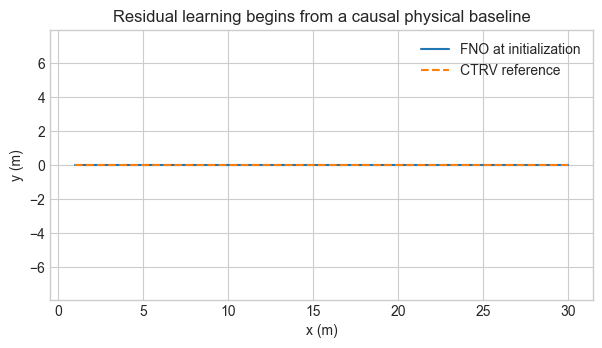

In [5]:
# Verify the zero-initialized residual starts exactly at the CTRV reference.
from zod_driveformer.models.baselines import constant_turn_rate_velocity
physical_reference = constant_turn_rate_velocity(
    torch.tensor([10.,10.]), torch.tensor([0.,0.]), future_steps=30, dt=.1
)
print("maximum initialization residual:", (trajectory-physical_reference).abs().max().item())
plt.figure(figsize=(7,3.5)); plt.plot(trajectory[0,:,0], trajectory[0,:,1], label='FNO at initialization')
plt.plot(physical_reference[0,:,0], physical_reference[0,:,1], '--', label='CTRV reference')
plt.axis('equal'); plt.xlabel('x (m)'); plt.ylabel('y (m)'); plt.legend();
plt.title('Residual learning begins from a causal physical baseline'); plt.show()

## Why padding exists

FFT assumes periodic boundaries: the last time point wraps to the first. A
driving history is not periodic. Zero-padding before spectral blocks increases
the distance between the physical boundaries, reducing wrap-around artifacts;
the padded tail is removed before prediction.

The padding is eight grid steps in the frozen model. It does not create future
information: all added entries are deterministic zeros.

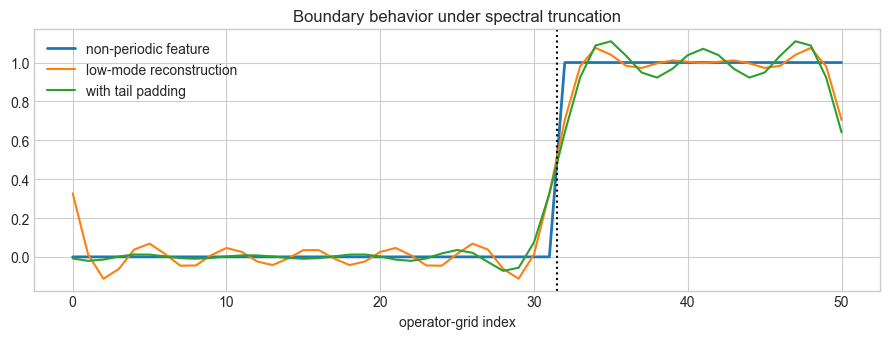

In [6]:
step = np.r_[np.zeros(32), np.ones(19)]
spec = np.fft.rfft(step)
unfiltered = np.fft.irfft(spec, n=len(step))
filtered_spec = spec.copy(); filtered_spec[10:] = 0
filtered = np.fft.irfft(filtered_spec, n=len(step))
padded = np.pad(step, (0,8)); padded_spec=np.fft.rfft(padded); padded_spec[10:]=0
padded_filtered=np.fft.irfft(padded_spec,n=len(padded))[:len(step)]
plt.figure(figsize=(9,3.5)); plt.plot(step,label='non-periodic feature',lw=2)
plt.plot(filtered,label='low-mode reconstruction'); plt.plot(padded_filtered,label='with tail padding')
plt.axvline(31.5,color='black',ls=':'); plt.legend(); plt.title('Boundary behavior under spectral truncation')
plt.xlabel('operator-grid index'); plt.tight_layout(); plt.show()

## Training loss and model selection

Temporal FNO is not an ODE and therefore does not use multiple shooting. It is
trained directly with full-horizon trajectory loss

\[
\mathcal L_{FNO}=\frac1{BT}\sum_{i=1}^{B}\sum_{t=1}^{T}
\lVert\hat y_{i,t}-y_{i,t}\rVert_2.
\]

The checkpoint with minimum validation ADE is selected independently for each
seed. Test metrics are computed only after selection is frozen.

In [7]:
entry = summary["dynamics"]["paired_difference_candidate_minus_b2"]["temporal_fno"]["delta_ade_m"]
print(f"FNO − B2 ADE: {entry['estimate']:+.4f} m")
print(f"95% grouped interval: [{entry['lower']:+.4f}, {entry['upper']:+.4f}] m")

FNO − B2 ADE: -0.1308 m
95% grouped interval: [-0.1546, -0.1080] m


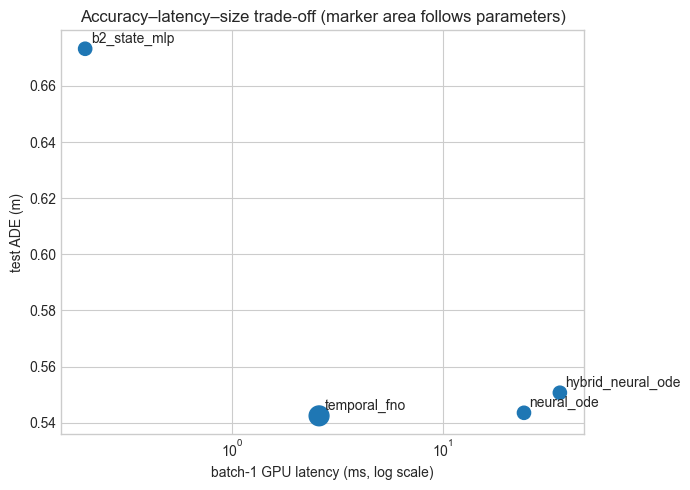

In [8]:
models = summary['dynamics']['models']
comparison=[]
for name in ('b2_state_mlp','hybrid_neural_ode','neural_ode','temporal_fno'):
    e=models[name]
    comparison.append((name,e['metrics_across_seeds']['ade_m']['mean'],
                       e['latency']['batch_1_median_ms'],e['parameters']/1e6))
frame=pd.DataFrame(comparison,columns=['model','ADE_m','latency_ms','parameters_M'])
fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(frame.latency_ms,frame.ADE_m,s=80+100*frame.parameters_M)
for row in frame.itertuples(): ax.annotate(row.model,(row.latency_ms,row.ADE_m),xytext=(4,4),textcoords='offset points')
ax.set_xscale('log'); ax.set_xlabel('batch-1 GPU latency (ms, log scale)'); ax.set_ylabel('test ADE (m)')
ax.set_title('Accuracy–latency–size trade-off (marker area follows parameters)'); plt.tight_layout(); plt.show()

## Inspecting operator output in trajectory space

The red FNO curve below is not a frequency-domain diagnostic: it is the decoded
physical output in anchor-local metres, projected only for display. Comparing it
with ODE paths and ground truth checks that similar ADE is not hiding a different
failure mode. The learned curves average all three frozen seeds; the benchmark
itself averages per-seed metrics rather than scoring this visual ensemble.

![Camera-projected trajectory montage](../reports/figures/dynamics_camera_predictions.png)

![Animated held-out trajectory cases](../reports/figures/dynamics_camera_predictions.gif)

## A careful conclusion

The project does not establish that FNO is universally superior to ODE models.
FNO's ADE is 0.0011 m below NeuralODE, a negligible raw gap without a direct
superiority claim. The evidence establishes a stronger engineering fact: FNO
preserves ODE-level accuracy while reducing batch-1 latency from 24.45 ms to
2.69 ms on the same GPU.

### Check my understanding

- Global Fourier mixing is causal here because future slots contain queries,
  not future measurements.
- The zero-initialized residual head makes the initial model equal CTRV.
- Padding mitigates FFT wrap-around but does not change the physical grid.
- “Best” means the promoted accuracy–latency choice, not universal dominance.